In [1]:
# Optional: uncomment if running in an environment where packages are missing
# %pip install numpy pandas matplotlib seaborn scikit-learn

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.colors import ListedColormap
from sklearn.datasets import make_moons, make_classification, make_circles, load_breast_cancer
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    mean_squared_error,
    r2_score
)

# Global visualization settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
np.set_printoptions(precision=4, suppress=True)

# Colors for consistent visualization
COLOR_CLASS_0 = "#2a9d8f"  # Teal
COLOR_CLASS_1 = "#e76f51"  # Coral
COLOR_ENSEMBLE = "#1f6feb" # Blue
COLOR_ACCENT = "#f4a261"   # Sand / Gold


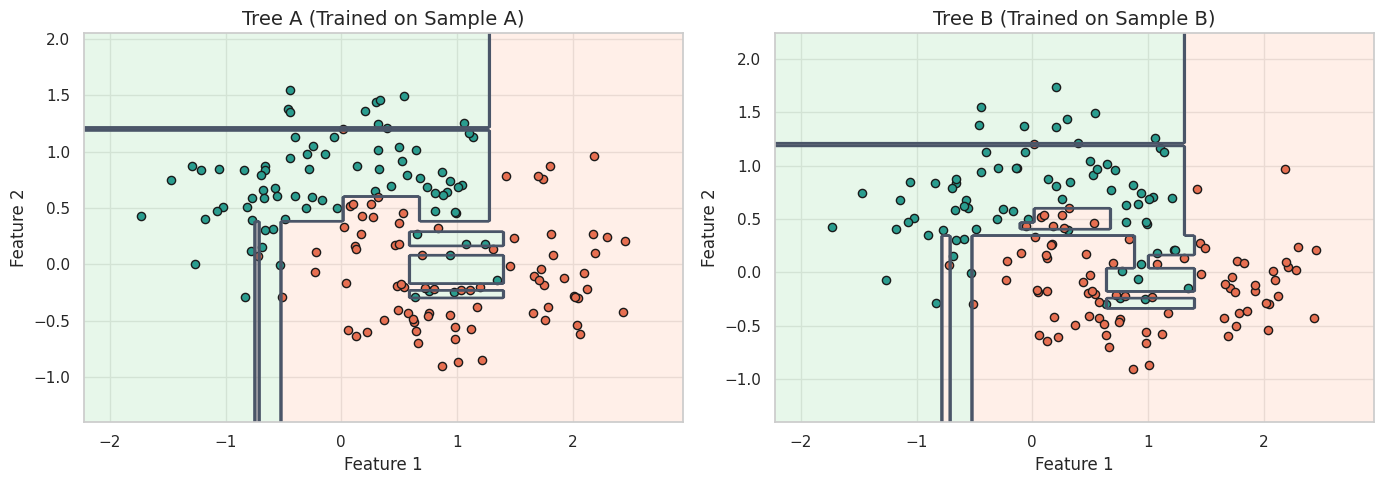

In [5]:
X_demo, y_demo = make_moons(n_samples=200, noise=0.30, random_state=42)

rng = np.random.RandomState(10)

indices_A = rng.choice(np.arange(X_demo.shape[0]), size=160, replace=False)
indices_B = rng.choice(np.arange(X_demo.shape[0]), size=160, replace=False)

X_demo_A = X_demo[indices_A]
X_demo_B = X_demo[indices_B]

y_demo_A = y_demo[indices_A]
y_demo_B = y_demo[indices_B]

tree_A = DecisionTreeClassifier(random_state=0)
tree_A.fit(X_demo_A, y_demo_A)

tree_B = DecisionTreeClassifier(random_state=0)
tree_B.fit(X_demo_B, y_demo_B)

# Helper function to plot decision boundaries
def plot_boundary(clf, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    cmap_bg = ListedColormap(["#d8f3dc", "#ffe5d9"])
    ax.contourf(xx, yy, Z, alpha=0.6, cmap=cmap_bg)
    ax.contour(xx, yy, Z, colors="#4a5568", linewidths=1.0)
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c=COLOR_CLASS_0, edgecolors="k", s=35, label="Class 0")
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c=COLOR_CLASS_1, edgecolors="k", s=35, label="Class 1")
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
plot_boundary(tree_A, X_demo[indices_A], y_demo[indices_A], ax1, "Tree A (Trained on Sample A)")
plot_boundary(tree_B, X_demo[indices_B], y_demo[indices_B], ax2, "Tree B (Trained on Sample B)")
plt.tight_layout()
plt.show()

In [12]:
# bootstrapping
size = 10000
toy_rows = np.array([f"Row_{i}" for i in range(size)])

rng = np.random.RandomState(10)

# Draw 10 samples with replacement
sample_indices = rng.choice(size, size=size, replace=True)
bootstrap_sample = toy_rows[sample_indices]
unique_in_bag = np.unique(sample_indices)
oob_indices = np.setdiff1d(np.arange(size), unique_in_bag)

print(f"Original rows: {list(range(size))}")
print(f"Drawn with replacement: {sample_indices.tolist()}")
print(f"Unique rows in bag ({len(unique_in_bag)} / size = {len(unique_in_bag)*size}%): {unique_in_bag.tolist()}")
print(f"Out-of-Bag rows ({len(oob_indices)} / size = {len(oob_indices)*10}%): {oob_indices.tolist()}")


Original rows: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218,

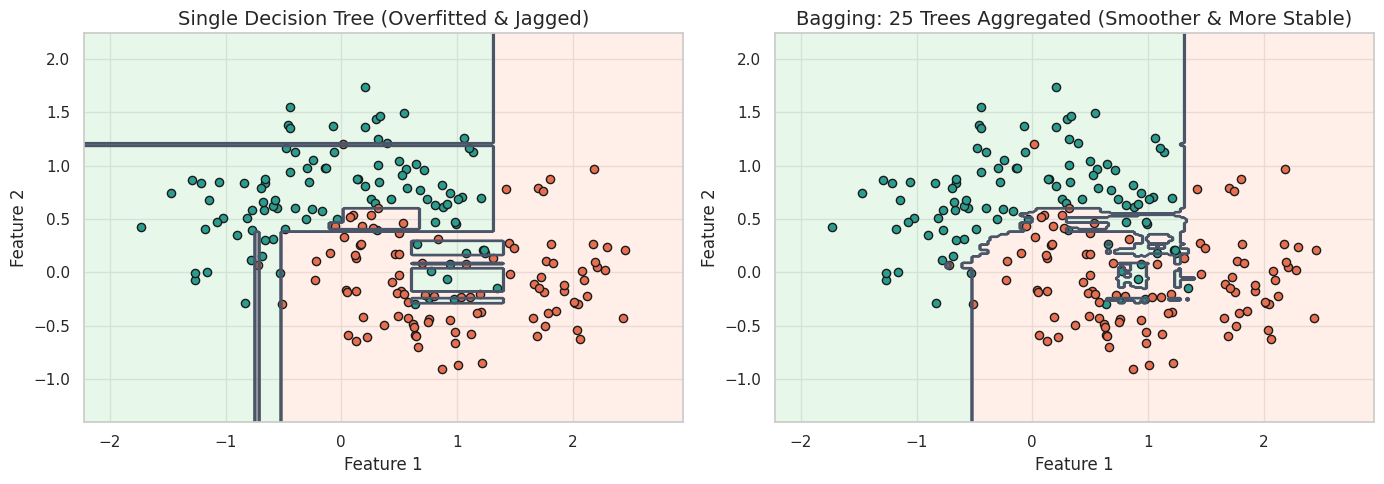

In [14]:
class SimpleBaggingClassifier():
    def __init__(self, n_estimators=20, random_state=42):
        self.n_estimators = n_estimators
        self.random_state = random_state
        self.trees = []

    def fit(self, X, y):
        rng = np.random.RandomState(self.random_state)
        n_samples = len(X)
        for i in range(self.n_estimators):
            boot_idx = rng.choice(n_samples, size=n_samples, replace=True)
            tree = DecisionTreeClassifier(random_state=self.random_state)
            tree.fit(X[boot_idx], y[boot_idx])
            self.trees.append(tree)
        return self

    def predict_proba(self, X):
        preds = np.array([tree.predict_proba(X) for tree in self.trees])
        return np.mean(preds, axis=0)

    def predict(self, X):
        proba = self.predict_proba(X)
        return np.argmax(proba, axis=1)


# bagging_model = SimpleBaggingClassifier(n_estimators=25, random_state=42)
# bagging_model.fit(X_demo, y_demo)

bagging_model = SimpleBaggingClassifier(n_estimators=25, random_state=42).fit(X_demo, y_demo)
single_tree = DecisionTreeClassifier(random_state=42).fit(X_demo, y_demo)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
plot_boundary(single_tree, X_demo, y_demo, ax1, "Single Decision Tree (Overfitted & Jagged)")
plot_boundary(bagging_model, X_demo, y_demo, ax2, "Bagging: 25 Trees Aggregated (Smoother & More Stable)")
plt.tight_layout()
plt.show()

In [44]:
class RandomForestClassifierScratch():
    def __init__(self, n_estimators=20, max_depth=None, min_samples_split=2, max_features=None, random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.random_state = random_state

        self.trees = []
        self.oob_indices_per_tree = []
        self.classes = None
        self.n_classes = None

    def bootstrap_sample(self, X, y):
        n_samples = len(X)
        rng = np.random.RandomState(self.random_state)
        boot_idx = rng.choice(n_samples, size=n_samples, replace=True)
        oob_idx = np.setdiff1d(np.arange(n_samples), boot_idx)
        return boot_idx, oob_idx

    def fit(self, X, y):
        rng = np.random.RandomState(self.random_state)
        X = np.asarray(X)
        y = np.asarray(y)

        self.classes = np.unique(y)
        self.n_classes = len(self.classes)

        for i in range(self.n_estimators):
            in_bag_idx, oob_idx = self.bootstrap_sample(X, y)
            self.oob_indices_per_tree.append(oob_idx)

            tree = DecisionTreeClassifier(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                max_features=self.max_features,
                random_state=np.random.randint(10000)
            )
            tree.fit(X[in_bag_idx], y[in_bag_idx])
            self.trees.append(tree)

        return self

    def predict_proba(self, X):
        preds = np.array([tree.predict_proba(X) for tree in self.trees])
        return np.mean(preds, axis=0)

    def predict(self, X):
        proba = self.predict_proba(X)
        return self.classes[np.argmax(proba, axis=1)]

    def compute_oob_score(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        n_samples = len(X)

        oob_probas = np.zeros((n_samples, self.n_classes))
        oob_counts = np.zeros(n_samples)

        for tree, oob_idx in zip(self.trees, self.oob_indices_per_tree):
            if len(oob_idx) > 0:
                preds = tree.predict_proba(X[oob_idx])
                oob_probas[oob_idx] += preds
                oob_counts[oob_idx] += 1

        # Only evaluate samples that were OOB in at least one tree
        evaluated_mask = oob_counts > 0
        if not np.any(evaluated_mask):
            return 0.0

        final_oob_probas = oob_probas[evaluated_mask] / oob_counts[evaluated_mask, None]
        oob_preds = self.classes[np.argmax(final_oob_probas, axis=1)]

        return accuracy_score(y[evaluated_mask], oob_preds)



In [47]:
class RandomForestClassifierScratch:
    def __init__(self, n_estimators=50, max_depth=None, min_samples_split=2,
                 max_features="sqrt", random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.random_state = random_state

        self.trees = []
        self.oob_indices_per_tree = []
        self.classes_ = None
        self.n_classes_ = None

    def _bootstrap_sample(self, X, y, rng):
        """Draw N samples with replacement and track in-bag and out-of-bag indices."""
        n_samples = len(X)
        in_bag_idx = rng.choice(n_samples, size=n_samples, replace=True)
        unique_in_bag = np.unique(in_bag_idx)
        oob_idx = np.setdiff1d(np.arange(n_samples), unique_in_bag)
        return in_bag_idx, oob_idx

    def fit(self, X, y):
        rng = np.random.RandomState(self.random_state)
        X = np.asarray(X)
        y = np.asarray(y)

        self.classes_ = np.unique(y)
        self.n_classes_ = len(self.classes_)
        self.trees = []
        self.oob_indices_per_tree = []

        for i in range(self.n_estimators):
            in_bag_idx, oob_idx = self._bootstrap_sample(X, y, rng)

            # Each tree uses a random subset of features at each split via max_features
            tree = DecisionTreeClassifier(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                max_features=self.max_features,
                random_state=rng.randint(10000)
            )
            tree.fit(X[in_bag_idx], y[in_bag_idx])

            self.trees.append(tree)
            self.oob_indices_per_tree.append(oob_idx)

        return self

    def predict_proba(self, X):
        """Soft voting: average predicted probabilities across all trees."""
        X = np.asarray(X)
        tree_probas = np.array([tree.predict_proba(X) for tree in self.trees])
        return np.mean(tree_probas, axis=0)

    def predict(self, X):
        probas = self.predict_proba(X)
        return self.classes_[np.argmax(probas, axis=1)]

    def compute_oob_score(self, X, y):
        """
        Compute the Out-Of-Bag accuracy:
        For each row i, aggregate predictions only from the trees where row i was OOB.
        """
        X = np.asarray(X)
        y = np.asarray(y)
        n_samples = len(X)

        # Accumulate out-of-bag probability predictions for each sample
        oob_probas = np.zeros((n_samples, self.n_classes_))
        oob_counts = np.zeros(n_samples)

        for tree, oob_idx in zip(self.trees, self.oob_indices_per_tree):
            if len(oob_idx) > 0:
                preds = tree.predict_proba(X[oob_idx])
                oob_probas[oob_idx] += preds
                oob_counts[oob_idx] += 1

        # Only evaluate samples that were OOB in at least one tree
        evaluated_mask = oob_counts > 0
        if not np.any(evaluated_mask):
            return 0.0

        final_oob_probas = oob_probas[evaluated_mask] / oob_counts[evaluated_mask, None]
        oob_preds = self.classes_[np.argmax(final_oob_probas, axis=1)]

        return accuracy_score(y[evaluated_mask], oob_preds)


In [48]:
# Split the demo dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_demo, y_demo, test_size=0.30, random_state=42, stratify=y_demo
)

rf_scratch = RandomForestClassifierScratch(n_estimators=25, max_features='sqrt', random_state=42)
rf_scratch.fit(X_train, y_train)

train_acc = accuracy_score(y_train, rf_scratch.predict(X_train))
test_acc = accuracy_score(y_test, rf_scratch.predict(X_test))
oob_acc = rf_scratch.compute_oob_score(X_train, y_train)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"OOB Accuracy: {oob_acc:.4f}")


Train Accuracy: 0.9929
Test Accuracy: 0.9500
OOB Accuracy: 0.8929


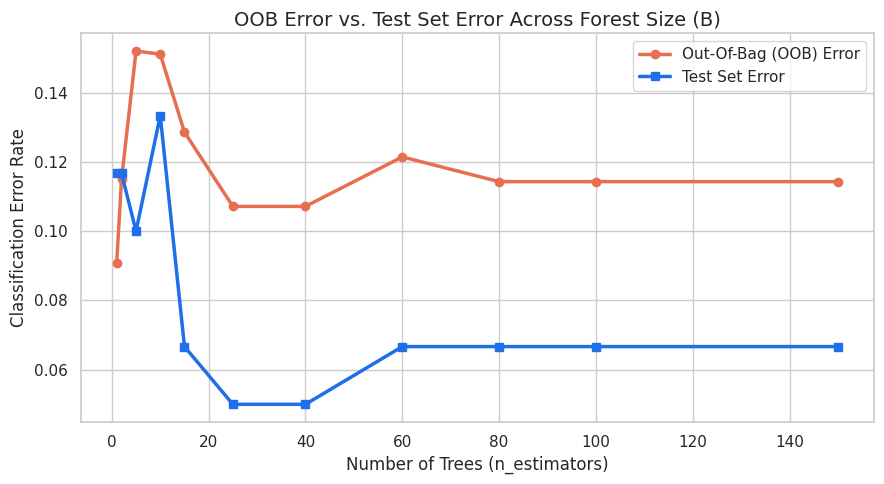

In [49]:
tree_counts = [1, 2, 5, 10, 15, 25, 40, 60, 80, 100, 150]
oob_errors = []
test_errors = []

for B in tree_counts:
    rf_scratch = RandomForestClassifierScratch(n_estimators=B, max_features='sqrt', random_state=42)
    rf_scratch.fit(X_train, y_train)

    oob_acc = rf_scratch.compute_oob_score(X_train, y_train)
    test_acc = accuracy_score(y_test, rf_scratch.predict(X_test))

    oob_errors.append(1 - oob_acc)
    test_errors.append(1 - test_acc)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(tree_counts, oob_errors, marker="o", color="#e76f51", lw=2.5, label="Out-Of-Bag (OOB) Error")
ax.plot(tree_counts, test_errors, marker="s", color="#1f6feb", lw=2.5, label="Test Set Error")

ax.set_title("OOB Error vs. Test Set Error Across Forest Size (B)")
ax.set_xlabel("Number of Trees (n_estimators)")
ax.set_ylabel("Classification Error Rate")
ax.legend(frameon=True, fontsize=11)
plt.tight_layout()
plt.show()

In [33]:
rf = RandomForestClassifier(n_estimators=100, max_features='sqrt', oob_score=True)
rf.fit(X_train, y_train)


RandomForestClassifier(oob_score=True)

In [52]:
# get rf oob score
train_acc = accuracy_score(y_train, rf.predict(X_train))
test_acc = accuracy_score(y_test, rf.predict(X_test))
oob_acc = rf.oob_score_
oob_acc

0.8928571428571429